<a href="https://colab.research.google.com/github/viragantlasai-code/BRIDGE-LOAD-DISTRIBUTION-CALCULATOR-/blob/main/Bridge_load_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# BRIDGE LOAD DISTRIBUTION CALCULATOR (A2)
# B.Tech Mathematics Mini Project
# ============================================================

print("BRIDGE LOAD DISTRIBUTION CALCULATOR")
print("=" * 55)

print("""
Mathematical Model:
    A X = B

Unknowns:
    X = [R1, R2, R3]
    R1, R2, R3 = reaction forces at the three supports

Engineering assumption:
    The bridge deck is treated as a rigid beam.
    The three supports are vertical linear-elastic supports
    with known stiffness values.

The three equations are:
    1. Vertical force equilibrium
    2. Moment equilibrium
    3. Support compatibility
""")

BRIDGE LOAD DISTRIBUTION CALCULATOR

Mathematical Model:
    A X = B

Unknowns:
    X = [R1, R2, R3]
    R1, R2, R3 = reaction forces at the three supports

Engineering assumption:
    The bridge deck is treated as a rigid beam.
    The three supports are vertical linear-elastic supports
    with known stiffness values.

The three equations are:
    1. Vertical force equilibrium
    2. Moment equilibrium
    3. Support compatibility



In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# NumPy    -> numerical calculations
# SymPy    -> symbolic mathematics and readable equations
# Matplotlib -> charts and visualizations

np.set_printoptions(precision=4, suppress=True)

In [ ]:
# ============================================================
# INPUT CONFIGURATION
# ============================================================

# Support positions in metres
support_positions = np.array([
    0.0,    # Support 1
    5.0,    # Support 2
    10.0    # Support 3
])

# Support stiffness in N/m
# For the benchmark, all three supports have equal stiffness.
support_stiffness = np.array([
    1_000_000.0,   # k1
    1_000_000.0,   # k2
    1_000_000.0    # k3
])

# Loads are entered as:
# (load in Newtons, position in metres)

loads_before = [
    (100_000.0, 2.0),   # 100 kN at 2 m
    (150_000.0, 6.0),   # 150 kN at 6 m
    (200_000.0, 8.0)    # 200 kN truck at 8 m
]

# The truck moves from 8 m to 6 m
truck_old_position = 8.0
truck_new_position = 6.0

# Truck load remains 200 kN
truck_load = 200_000.0

In [ ]:
# ============================================================
# DISPLAY INPUTS
# ============================================================

print("SUPPORT INFORMATION")
print("-" * 40)

for i, (x, k) in enumerate(zip(support_positions, support_stiffness), start=1):
    print(f"Support {i}: position = {x:.2f} m, stiffness = {k:,.0f} N/m")

print("\nLOAD INFORMATION")
print("-" * 40)

for i, (load, position) in enumerate(loads_before, start=1):
    print(
        f"Load {i}: {load/1000:.2f} kN at position {position:.2f} m"
    )

print(f"\nTruck moves: {truck_old_position:.2f} m -> "
      f"{truck_new_position:.2f} m")

SUPPORT INFORMATION
----------------------------------------
Support 1: position = 0.00 m, stiffness = 1,000,000 N/m
Support 2: position = 5.00 m, stiffness = 1,000,000 N/m
Support 3: position = 10.00 m, stiffness = 1,000,000 N/m

LOAD INFORMATION
----------------------------------------
Load 1: 100.00 kN at position 2.00 m
Load 2: 150.00 kN at position 6.00 m
Load 3: 200.00 kN at position 8.00 m

Truck moves: 8.00 m -> 6.00 m


In [ ]:
# ============================================================
# MATHEMATICAL MODEL
# ============================================================

def build_matrix_model(support_positions, support_stiffness, loads):
    """
    Build the 3x3 system A X = B.

    Unknown vector:
        X = [R1, R2, R3]

    Equations:
        1. Vertical force equilibrium
        2. Moment equilibrium about x = 0
        3. Compatibility of support deflections
    """

    x1, x2, x3 = support_positions
    k1, k2, k3 = support_stiffness

    # Check support positions are distinct
    if not (x1 < x2 < x3):
        raise ValueError(
            "Support positions must satisfy x1 < x2 < x3."
        )

    # Total downward load
    total_load = sum(load for load, position in loads)

    # Total moment of loads about x = 0
    total_moment = sum(load * position for load, position in loads)

    # --------------------------------------------------------
    # Equation 1:
    # R1 + R2 + R3 = total_load
    # --------------------------------------------------------

    row1 = [1.0, 1.0, 1.0]

    # --------------------------------------------------------
    # Equation 2:
    # x1 R1 + x2 R2 + x3 R3 = total_moment
    # --------------------------------------------------------

    row2 = [x1, x2, x3]

    # --------------------------------------------------------
    # Equation 3:
    #
    # (R2/k2 - R1/k1)/(x2-x1)
    # =
    # (R3/k3 - R2/k2)/(x3-x2)
    #
    # Rearranged into:
    #
    # a31 R1 + a32 R2 + a33 R3 = 0
    # --------------------------------------------------------

    a31 = -1 / (k1 * (x2 - x1))

    a32 = (
        1 / (k2 * (x2 - x1))
        + 1 / (k2 * (x3 - x2))
    )

    a33 = -1 / (k3 * (x3 - x2))

    row3 = [a31, a32, a33]

    A = np.array([row1, row2, row3], dtype=float)

    B = np.array([
        total_load,
        total_moment,
        0.0
    ], dtype=float)

    return A, B

In [ ]:
# ============================================================
# BUILD A X = B
# ============================================================

A_before, B_before = build_matrix_model(
    support_positions,
    support_stiffness,
    loads_before
)

print("COEFFICIENT MATRIX A")
print("=" * 40)
print(A_before)

print("\nRIGHT-HAND VECTOR B")
print("=" * 40)
print(B_before)

COEFFICIENT MATRIX A
[[ 1.  1.  1.]
 [ 0.  5. 10.]
 [-0.  0. -0.]]

RIGHT-HAND VECTOR B
[ 450000. 2700000.       0.]


In [ ]:
# ============================================================
# DISPLAY THE MATHEMATICAL EQUATIONS
# ============================================================

R1, R2, R3 = sp.symbols("R1 R2 R3")

x1, x2, x3 = support_positions
k1, k2, k3 = support_stiffness

total_load = B_before[0]
total_moment = B_before[1]

eq1 = sp.Eq(R1 + R2 + R3, total_load)

eq2 = sp.Eq(
    x1*R1 + x2*R2 + x3*R3,
    total_moment
)

eq3 = sp.Eq(
    (R2/k2 - R1/k1) / (x2-x1),
    (R3/k3 - R2/k2) / (x3-x2)
)

print("MATHEMATICAL EQUATIONS")
print("=" * 55)

print("\nEquation 1: Force equilibrium")
sp.pprint(eq1)

print("\nEquation 2: Moment equilibrium")
sp.pprint(eq2)

print("\nEquation 3: Compatibility")
sp.pprint(eq3)

MATHEMATICAL EQUATIONS

Equation 1: Force equilibrium
R₁ + R₂ + R₃ = 450000.0

Equation 2: Moment equilibrium
5.0⋅R₂ + 10.0⋅R₃ = 2700000.0

Equation 3: Compatibility
-2.0e-7⋅R₁ + 2.0e-7⋅R₂ = -2.0e-7⋅R₂ + 2.0e-7⋅R₃


In [ ]:
# ============================================================
# UNIQUE SOLUTION CHECK
# ============================================================

det_A = np.linalg.det(A_before)

print("UNIQUE SOLUTION CHECK")
print("=" * 40)

print(f"det(A) = {det_A:.6e}")

if np.isclose(det_A, 0.0):
    raise ValueError(
        "det(A) is zero or extremely close to zero. "
        "The system does not have a reliable unique solution."
    )

print("det(A) is non-zero.")
print("Therefore, A is invertible and the system has a unique solution.")

UNIQUE SOLUTION CHECK
det(A) = -6.000000e-06
det(A) is non-zero.
Therefore, A is invertible and the system has a unique solution.


In [ ]:
# ============================================================
# MATRIX INVERSE
# ============================================================

A_inverse = np.linalg.inv(A_before)

print("MATRIX INVERSE A⁻¹")
print("=" * 40)
print(A_inverse)

print("\nMathematical formula:")
print("X = A⁻¹ B")

MATRIX INVERSE A⁻¹
[[      0.8333      -0.1    -833333.3333]
 [      0.3333       0.     1666666.6667]
 [     -0.1667       0.1    -833333.3333]]

Mathematical formula:
X = A⁻¹ B


In [ ]:
# ============================================================
# SOLVE A X = B
# ============================================================

# Using the mathematical formula:
# X = A^(-1) B

X_before = A_inverse @ B_before

R_before = X_before

print("REACTION FORCES BEFORE TRUCK MOVES")
print("=" * 50)

for i, reaction in enumerate(R_before, start=1):
    print(f"Support {i}: {reaction/1000:.3f} kN")

REACTION FORCES BEFORE TRUCK MOVES
Support 1: 105.000 kN
Support 2: 150.000 kN
Support 3: 195.000 kN


In [ ]:
# ============================================================
# VERIFY SOLUTION
# ============================================================

B_reconstructed = A_before @ X_before

print("SOLUTION VERIFICATION")
print("=" * 50)

print("Original B:")
print(B_before)

print("\nCalculated A @ X:")
print(B_reconstructed)

print("\nMaximum numerical error:")
error = np.max(np.abs(B_before - B_reconstructed))
print(f"{error:.6e}")

if np.allclose(B_before, B_reconstructed):
    print("\n✓ Solution verified: A @ X = B")
else:
    print("\n✗ Verification failed")

SOLUTION VERIFICATION
Original B:
[ 450000. 2700000.       0.]

Calculated A @ X:
[ 450000. 2700000.       0.]

Maximum numerical error:
5.820766e-11

✓ Solution verified: A @ X = B


In [ ]:
# ============================================================
# TRUCK MOVEMENT
# ============================================================

# Create a new load configuration
loads_after = [
    (100_000.0, 2.0),   # Load 1
    (150_000.0, 6.0),   # Load 2

    # Truck has moved from 8 m to 6 m
    (truck_load, truck_new_position)
]

A_after, B_after = build_matrix_model(
    support_positions,
    support_stiffness,
    loads_after
)

# The matrix A remains the same because:
# - support positions did not change
# - support stiffnesses did not change
#
# B changes because the truck position changed.

R_after = np.linalg.solve(A_after, B_after)

print("TRUCK MOVEMENT")
print("=" * 50)

print(f"Old truck position: {truck_old_position:.2f} m")
print(f"New truck position: {truck_new_position:.2f} m")

print("\nREACTIONS AFTER TRUCK MOVES")

for i, reaction in enumerate(R_after, start=1):
    print(f"Support {i}: {reaction/1000:.3f} kN")

TRUCK MOVEMENT
Old truck position: 8.00 m
New truck position: 6.00 m

REACTIONS AFTER TRUCK MOVES
Support 1: 145.000 kN
Support 2: 150.000 kN
Support 3: 155.000 kN


In [ ]:
# ============================================================
# BEFORE vs AFTER
# ============================================================

print("REACTION FORCE COMPARISON")
print("=" * 65)

print(
    f"{'Support':<12}"
    f"{'Before (kN)':>15}"
    f"{'After (kN)':>15}"
    f"{'Change (kN)':>15}"
)

print("-" * 65)

for i in range(3):
    before = R_before[i] / 1000
    after = R_after[i] / 1000
    change = after - before

    print(
        f"{'Support ' + str(i+1):<12}"
        f"{before:>15.3f}"
        f"{after:>15.3f}"
        f"{change:>15.3f}"
    )

REACTION FORCE COMPARISON
Support         Before (kN)     After (kN)    Change (kN)
-----------------------------------------------------------------
Support 1           105.000        145.000         40.000
Support 2           150.000        150.000          0.000
Support 3           195.000        155.000        -40.000


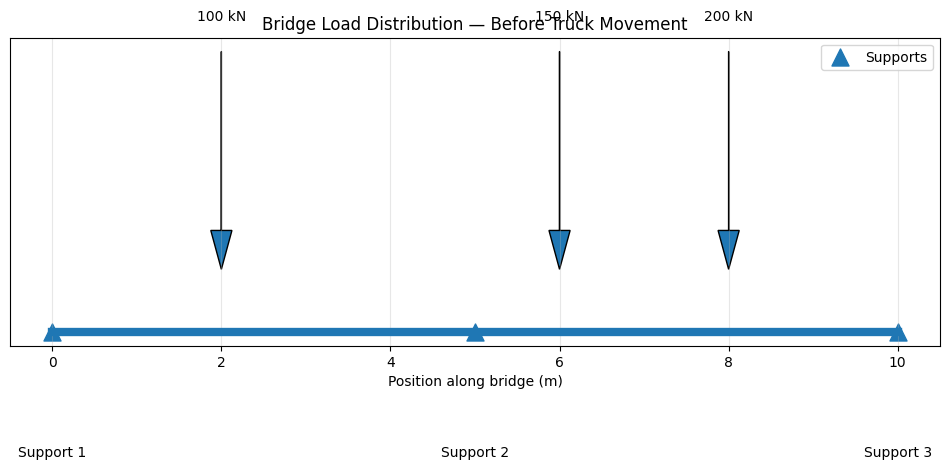

In [ ]:
# ============================================================
# BRIDGE LOAD DIAGRAM
# ============================================================

plt.figure(figsize=(12, 4))

# Bridge deck
plt.plot(
    [support_positions[0], support_positions[-1]],
    [0, 0],
    linewidth=6
)

# Supports
plt.scatter(
    support_positions,
    [0, 0, 0],
    s=150,
    marker="^",
    label="Supports"
)

# Loads before movement
for load, position in loads_before:
    plt.arrow(
        position, 1.8,
        0, -1.4,
        head_width=0.25,
        head_length=0.25,
        length_includes_head=True
    )

    plt.text(
        position,
        2.0,
        f"{load/1000:.0f} kN",
        ha="center"
    )

# Support labels
for i, position in enumerate(support_positions, start=1):
    plt.text(
        position,
        -0.8,
        f"Support {i}",
        ha="center"
    )

plt.title("Bridge Load Distribution — Before Truck Movement")
plt.xlabel("Position along bridge (m)")
plt.yticks([])

plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# ============================================================
# REACTION FORCE COMPARISON CHART
# ============================================================

supports = ["Support 1", "Support 2", "Support 3"]

before_kN = R_before / 1000
after_kN = R_after / 1000

x = np.arange(len(supports))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    before_kN,
    width,
    label="Before truck movement"
)

plt.bar(
    x + width/2,
    after_kN,
    width,
    label="After truck movement"
)

plt.xticks(x, supports)
plt.ylabel("Reaction force (kN)")
plt.title("Support Reaction Forces: Before vs After Truck Movement")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

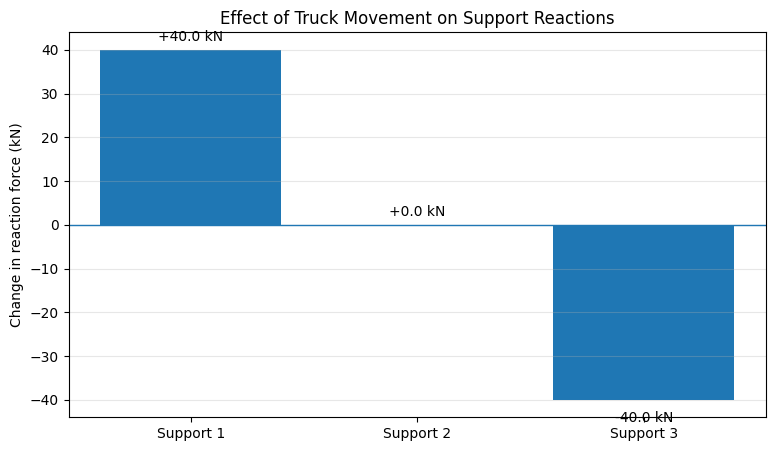

In [ ]:
# ============================================================
# CHANGE IN REACTION FORCES
# ============================================================

change_kN = (R_after - R_before) / 1000

plt.figure(figsize=(9, 5))

bars = plt.bar(
    supports,
    change_kN
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel("Change in reaction force (kN)")
plt.title("Effect of Truck Movement on Support Reactions")

plt.grid(axis="y", alpha=0.3)

# Display values above/below bars
for bar, value in zip(bars, change_kN):
    y = value + 2 if value >= 0 else value - 5

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{value:+.1f} kN",
        ha="center"
    )

plt.show()

In [ ]:
# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

total_load = sum(load for load, position in loads_before)

print("=" * 65)
print("FINAL PROJECT SUMMARY")
print("=" * 65)

print(f"""
Total bridge load: {total_load/1000:.2f} kN

Truck movement:
    {truck_old_position:.2f} m -> {truck_new_position:.2f} m

Mathematical model:
    A X = B

Unknown vector:
    X = [R1, R2, R3]

Solution:
    X = A⁻¹ B

Unique solution:
    Yes, because det(A) is non-zero.

Reaction forces BEFORE truck movement:
    R1 = {R_before[0]/1000:.3f} kN
    R2 = {R_before[1]/1000:.3f} kN
    R3 = {R_before[2]/1000:.3f} kN

Reaction forces AFTER truck movement:
    R1 = {R_after[0]/1000:.3f} kN
    R2 = {R_after[1]/1000:.3f} kN
    R3 = {R_after[2]/1000:.3f} kN

Main observation:
    Moving the truck changes the distribution of load
    among the three supports.
""")

FINAL PROJECT SUMMARY

Total bridge load: 450.00 kN

Truck movement:
    8.00 m -> 6.00 m

Mathematical model:
    A X = B

Unknown vector:
    X = [R1, R2, R3]

Solution:
    X = A⁻¹ B

Unique solution:
    Yes, because det(A) is non-zero.

Reaction forces BEFORE truck movement:
    R1 = 105.000 kN
    R2 = 150.000 kN
    R3 = 195.000 kN

Reaction forces AFTER truck movement:
    R1 = 145.000 kN
    R2 = 150.000 kN
    R3 = 155.000 kN

Main observation:
    Moving the truck changes the distribution of load
    among the three supports.

